In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, KFold
from sklearn.model_selection import cross_val_predict
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import optuna.visualization as vis

import os

from astropy.cosmology import FlatLambdaCDM



In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned_tripp_uncorrected_chi2_only.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 513 entries, 0 to 512
Data columns (total 69 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   ZTF_Unnamed: 0                    513 non-null    float64
 1   ztfname                           513 non-null    object 
 2   ZTF_redshift                      513 non-null    float64
 3   ZTF_redshift_err                  513 non-null    float64
 4   ZTF_source                        513 non-null    object 
 5   ZTF_t0                            513 non-null    float64
 6   ZTF_x0                            513 non-null    float64
 7   ZTF_x1                            513 non-null    float64
 8   ZTF_c                             513 non-null    float64
 9   ZTF_t0_err                        513 non-null    float64
 10  ZTF_x0_err                        513 non-null    float64
 11  ZTF_x1_err                        513 non-null    float64
 12  ZTF_c_er

In [3]:
feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
    "DESI_METADATA_Z",
    "ZTF_c",
    "ZTF_x1",
]

target_col = "residuals"

yerr_all = df["ZTF_sigma_mu"]

X = df[feature_cols]
y = df[target_col]

In [4]:
# No train/test split — we use 5-fold CV on the full dataset
X_np = X.to_numpy()
y_np = y.to_numpy()


# Defining Optuna Study Objective #

Here we have to set a "reasonable" range of hyperparameters to tune for the random forest. This is b/c optuna doesn't just start from scratch. 


The full list of Random Forest Hyperparameters can be found here: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

The parameters I choose to vary:

n_estimatorsint, default=100 The number of trees in the forest. varying from defualt to 1500 in steps of 100.
max_depthint, default=None The maximum depth of the tree. If None, then nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples. Ended up varying depth to some max amount. Did some trial and error to see what range is good. If the search settled on some smaller number, inceased to larger number and then dialed back so as not to waste computation space. 

min_samples_splitint or float, default=2 The minimum number of samples required to split an internal node: If int, then consider min_samples_split as the minimum number. If float, then min_samples_split is a fraction and ceil(min_samples_split * n_samples) are the minimum number of samples for each split. Started at the default and incrased to a larger number. 

min_samples_leafint or float, default=1
The minimum number of samples required to be at a leaf node. A split point at any depth will only be considered if it leaves at least min_samples_leaf training samples in each of the left and right branches. This may have the effect of smoothing the model, especially in regression.

If int, then consider min_samples_leaf as the minimum number. If float, then min_samples_leaf is a fraction and ceil(min_samples_leaf * n_samples) are the minimum number of samples for each node.

## `min_samples_leaf` — Controlling Leaf Bucket Size

`min_samples_leaf` sets the minimum number of SNe Ia allowed in any
final leaf node (bucket) of a decision tree.

- `min_samples_leaf=1`: A leaf can contain a single SN. That SN's
  Δμ becomes the prediction for anything landing in that bucket.
  This is essentially memorizing individual data points.

- `min_samples_leaf=10`: Every leaf must contain at least 10 SNe.
  The prediction is the average Δμ of those 10 SNe — a much
  smoother, more stable estimate that is harder to overfit.

Our Optuna search explores the range 1–10, letting the optimization
decide how granular the leaf buckets should be.

### Interaction with `max_depth`

These two hyperparameters control the same thing — tree complexity —
from opposite directions:

- `max_depth` limits complexity **from the top**: how many sequential
  splits a tree is allowed to make.
- `min_samples_leaf` limits complexity **from the bottom**: how small
  the resulting buckets can get.

With our best-fit `max_depth=3` (~8 leaf nodes for 521 SNe), even
`min_samples_leaf=1` is not dangerous because the tree is too shallow
to isolate individual SNe. However, if Optuna had selected
`max_depth=30`, then `min_samples_leaf` would serve as the safety
net preventing the tree from creating tiny, noise-dominated buckets.


# Max Features #

"max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]). Wnate dto play around what is better.



The parameters I choose to keep default:

criterion{“gini”, “entropy”, “log_loss”}, default=”gini”- b/c its the default method of criterion evaluation (See. 8.1.2 of "An Introductin to Statistical Learning")



In [5]:
def objective(trial):

    # Parameters we suggest to optimize and caps on their ranges.
    # Optuna will automatically sample values for these parameters within the specified ranges.
    # It will prune unpromising trials based on intermediate results. So not everything 
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 1500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "n_jobs": -1,
        "random_state": 42,
    }

    # only runs the following code if boostram is set to True.
    if params["bootstrap"]:
        params["max_samples"] = trial.suggest_float("max_samples", 0.5, 1.0)

    ## ** is python dictionary unpacking syntax
    # which allows us to pass the parameters as keyword arguments to the RandomForestRegressor constructor.
    rf = RandomForestRegressor(**params)

    # Creates a splitter object that will divide training data into 5 equal chunks. 
    # Shuffle True means that the data will be randomly shuffled before splitting
    # (ensures that each fold is representative of the overall dataset.). 
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    fold_scores = [] # for MSE scores of each fold

    # We had previously split the data into train/test (521/104)
    # 5-fold cross validation on the full 521 SNe.
    # Each fold: ~417 train and ~104 validation.
    for train_idx, val_idx in kf.split(X_np):
        X_fold_tr = X_np[train_idx]
        X_fold_val = X_np[val_idx]

        y_fold_tr = y_np[train_idx]
        y_fold_val = y_np[val_idx]

        rf.fit(X_fold_tr, y_fold_tr)
        y_fold_pred = rf.predict(X_fold_val)

        score = mean_squared_error(y_fold_val, y_fold_pred)
        fold_scores.append(score)

    # The Value Optuna is Minnimizing.
    return np.mean(fold_scores)

In [6]:
study_name = "optuna_runs_info/rf_prediction_uncorrected_tripp_host_chi2_only"

db_path = f"{study_name}.db"
if os.path.exists(db_path):
    os.remove(db_path)

study = optuna.create_study(direction="minimize", storage=f"sqlite:///{db_path}", study_name=study_name)
study.optimize(objective, n_trials=50, show_progress_bar=True) # 100 different hyperparameter combinations will be tried.

print("Best trial:", study.best_trial.number)
print("Best MSE:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

[I 2026-04-14 16:39:00,357] A new study created in RDB with name: optuna_runs_info/rf_prediction_uncorrected_tripp_host_chi2_only


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-14 16:39:01,038] Trial 0 finished with value: 0.05454947584143951 and parameters: {'n_estimators': 500, 'max_depth': 3, 'min_samples_split': 17, 'min_samples_leaf': 12, 'max_features': None, 'bootstrap': False}. Best is trial 0 with value: 0.05454947584143951.
[I 2026-04-14 16:39:02,961] Trial 1 finished with value: 0.042486064208197734 and parameters: {'n_estimators': 1000, 'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'bootstrap': True, 'max_samples': 0.6872002926615872}. Best is trial 1 with value: 0.042486064208197734.
[I 2026-04-14 16:39:03,263] Trial 2 finished with value: 0.057334904266268215 and parameters: {'n_estimators': 100, 'max_depth': 3, 'min_samples_split': 18, 'min_samples_leaf': 15, 'max_features': 'sqrt', 'bootstrap': True, 'max_samples': 0.8475137320857986}. Best is trial 1 with value: 0.042486064208197734.
[I 2026-04-14 16:39:04,732] Trial 3 finished with value: 0.04919815648503277 and parameters: {'n_estimators'

$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(\Delta\mu_i - \Delta\mu_{\rm ML, predict})^2}$

In [7]:
best_params = study.best_params.copy()
print(best_params)
best_params["n_jobs"] = -1
best_params["random_state"] = 42

rf = RandomForestRegressor(**best_params)
rf.fit(X, y)
y_pred = rf.predict(X)

# RMS of prediction residuals
rms = np.sqrt(np.mean((y.to_numpy() - y_pred) ** 2))

print("RMS:", rms)

{'n_estimators': 900, 'max_depth': 14, 'min_samples_split': 16, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True, 'max_samples': 0.801423245872187}
RMS: 0.13905514040528558


RMS of corrected residuals: 0.13939596438022755
ZTF_c                      0.703311
ZTF_x1                     0.197653
DESI_METADATA_Z            0.034571
DESI_FASTSPEC_DN4000       0.015596
DESI_FASTSPEC_g_minus_r    0.014381
DESI_FASTSPEC_AGE          0.010736
DESI_FASTSPEC_LOGMSTAR     0.008830
DESI_FASTSPEC_SFR          0.008122
DESI_FASTSPEC_VDISP        0.006801
dtype: float64


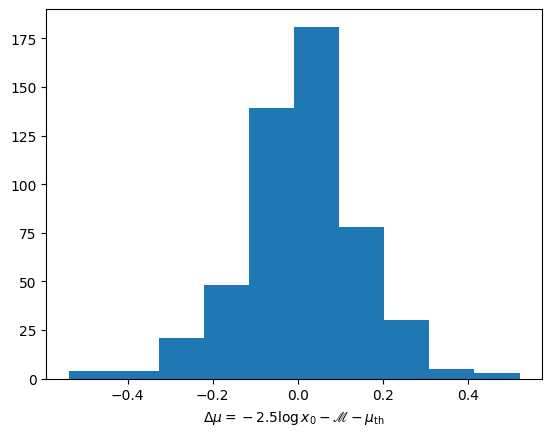

In [12]:
# Define the following global parameters:

alpha = 0.161
beta  = 3.05

df["ZTF_mu_obs"] = -2.5 * np.log10(df["ZTF_x0"])

# Define the following cosmology:
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Evaluate the cosmology at the ZTF reported redshift. We are using the ZTF redshift instead of DESI
# b/c we're propagating the ZTF uncertainty and we want to keep everything in the same data set. 

mu_th = cosmo.distmod(df["ZTF_redshift"]).value
corrected_residuals = df["ZTF_mu_obs"] - mu_th - (-29.759687) - y_pred

plt.hist(corrected_residuals)
plt.xlabel(r"$\Delta\mu = -2.5\log x_0 - \mathscr{M} - \mu_{\rm th}$")


rms_corrected = np.sqrt(np.mean(corrected_residuals ** 2))
print("RMS of corrected residuals:", rms_corrected)

feature_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(feature_importances)

## Why predictions Seem Like they are Capped

The predicted residuals span a much narrower range than the true residuals.
This is expected behavior when the features carry little predictive signal.

Each Random Forest prediction is the average of `n_predictors` individual tree
predictions. When the features (host galaxy properties) do not strongly
determine the target (Hubble residuals), each tree essentially guesses
near the sample mean. Averaging 1,000 near-zero guesses produces
predictions tightly clustered around zero.

This is consistent with a null result: host galaxy properties do not
significantly predict Hubble residuals beyond the Tripp correction.

Input from Dr. Armin Rest this shows evidence that our assumptions about
the fact that host galaxies give some form of nonlinear non parametric relations/corrections
to the Hubble residuals. 

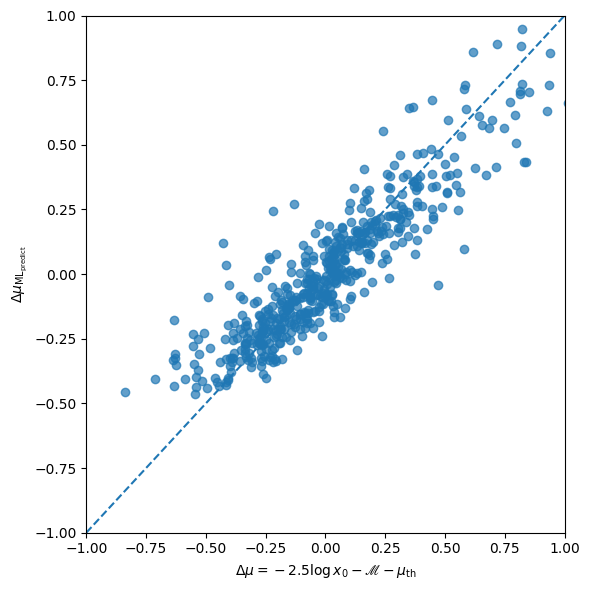

In [9]:
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, alpha=0.7)
plt.xlabel(r"$\Delta\mu = -2.5\log x_0 - \mathscr{M} - \mu_{\rm th}$")
plt.ylabel(r"$\Delta\mu_{\mathrm{ML}_{\mathrm{predict}}}$")
plt.axline((0, 0), slope=1, linestyle="--")

plt.xlim(-1, 1)
plt.ylim(-1, 1)

plt.tight_layout()
plt.show()